# import stuff

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PyAstronomy import pyasl #for fetching temperatures from stellar spectral types

from matplotlib.ticker import LogLocator, FuncFormatter #for handling ticklabels on plot

# read in data

In [2]:
#closest stars
closest = pd.read_csv('closest_stars.csv')

#brightest stars
brightest = pd.read_csv('brightest_stars.csv')

#lookup table
lookup_table = pd.read_csv('SpT_Lookup.csv')
lookup_table['spec_class'] = lookup_table['SpT'].str.replace('V', '').str.strip()

# function for converting spectral type to temperature

In [3]:
def spectral_to_temp(spectral_type):
    """
    Convert spectral type to temperature in Kelvin.
    Uses PyAstronomy package with de Jager & Nieuwenhuijzen (1987) calibration.
    """
    
    #parse spectral type string
    spec_str = str(spectral_type).strip()
    
    #separate spectral class & luminosity class by splitting string where there is a space
    parts = spec_str.split()
    spec_class = parts[0]
    
    #find match in lookup table
    match = lookup_table[lookup_table['spec_class'] == spec_class]
    
    #raise error if no match is found
    if match.empty:
        print(f"No exact match found for spectral type {spec_class}")
        return None
        
    #return corresponding effective temperature
    return match['Teff'].values[0]

# function for calculating luminosity from absolute magnitude

In [4]:
def mag_to_lum(M_star):
    """
    Convert absolute magnitude to luminosity in units of L_☉ (for ease)
    Equation derived from lecture slides
    Solar absolute magnitude approximated to M_☉ = 4.83
    """
    
    #define absolute magnitude of the sun
    M_sun = 4.83
    
    #calculate luminosity given absolute magnitude of star
    L = 10**(0.4*(M_sun - M_star))
    
    #return calculated luminosity
    return L

# scientific notation function for axis tick label making

In [12]:
def sci_notation(x, pos):
    exponent = int(np.floor(np.log10(x)))
    coeff = x / 10**exponent

    if np.isclose(coeff, 1):
        return rf"$10^{{{exponent}}}$"
    else:
        return rf"${int(coeff)}\times10^{{{exponent}}}$"

# apply functions to datasets

In [5]:
#calculate temp. and luminosity for closest stars
closest['Temperature (K)'] = closest['Spectral Type'].apply(spectral_to_temp)
closest['Luminosity (L_☉)'] = closest['Absolute Magnitude'].apply(mag_to_lum)

#calculate temp. and luminosity for brightest stars
brightest['Temperature (K)'] = brightest['Spectral Type'].apply(spectral_to_temp)
brightest['Luminosity (L_☉)'] = brightest['Absolute Magnitude'].apply(mag_to_lum)

#add temperatures for Sirius B and Procyon B (white dwarfs) manually
closest.loc[closest['Common Name'] == 'Sirius B', 'Temperature (K)'] = 25200
closest.loc[closest['Common Name'] == 'Procyon B', 'Temperature (K)'] = 7740

No exact match found for spectral type DA
No exact match found for spectral type DQZ


# plot HR diagram

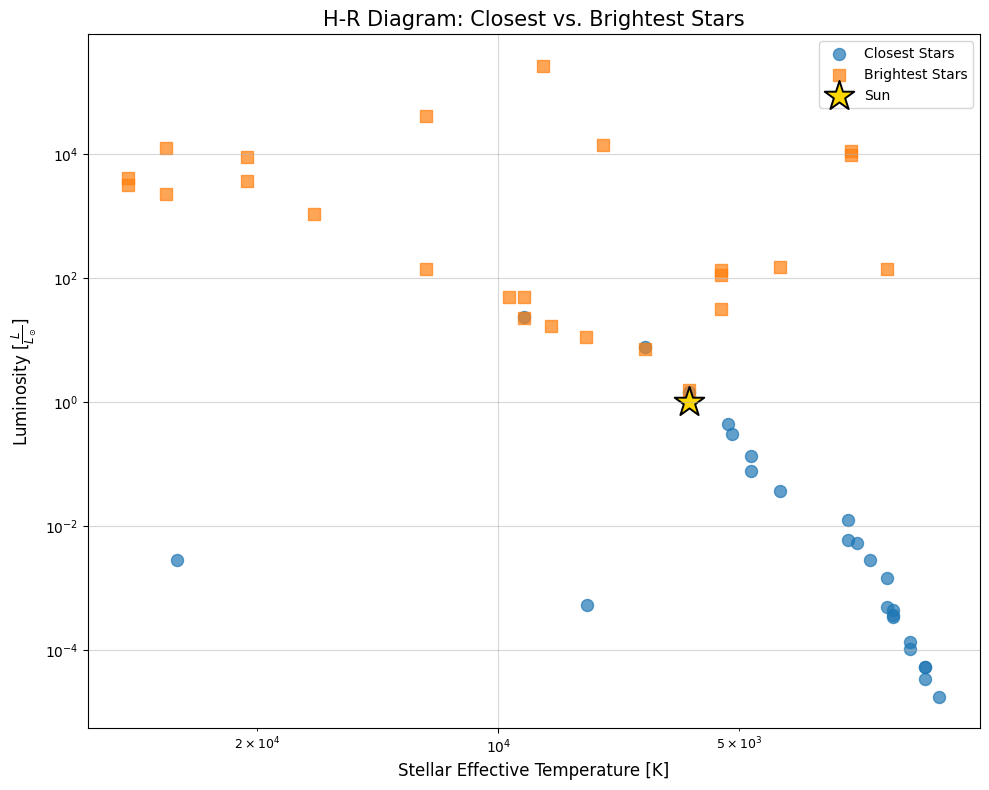

In [13]:
plt.figure(figsize = (10, 8))

plt.title('H-R Diagram: Closest vs. Brightest Stars', fontsize = 15)

#plot closest stars
plt.scatter(closest['Temperature (K)'], closest['Luminosity (L_☉)'], label = 'Closest Stars', marker = 'o', s = 75, alpha = 0.7)

#plot brightest stars
plt.scatter(brightest['Temperature (K)'], brightest['Luminosity (L_☉)'], label = 'Brightest Stars', marker = 's', s = 75, alpha = 0.7)

#add Sun for reference

T_sun = 5772
L_sun = 1.0

plt.scatter(T_sun, L_sun, marker = '*', s = 500, color = 'gold', edgecolor = 'black', linewidth = 1.4, label = 'Sun')

#set logarithmic scale to axes
plt.xscale('log')
plt.yscale('log')

#add specific ticks for x-axis
ax = plt.gca()

#major ticks: 10^n
ax.xaxis.set_major_locator(LogLocator(base = 10))

#set minor ticks ONLY at 2× and 5× (will be too crowded otherwise)
ax.xaxis.set_minor_locator(LogLocator(base = 10, subs = [2, 5]))

ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.xaxis.set_minor_formatter(FuncFormatter(sci_notation))

ax.tick_params(axis = 'x', which = 'minor', labelsize=9)

#invert x-axis so that we have hot --> cold
ax.invert_xaxis()

#add labels to axes
plt.xlabel('Stellar Effective Temperature [K]', fontsize = 12)
plt.ylabel('Luminosity [$\\frac{L}{L_\odot}$]', fontsize = 12)

#legend and grid
plt.legend(loc = 'best')
plt.grid(True, alpha = 0.5)

plt.tight_layout()

plt.savefig('HR_diagram.png', dpi = 300, bbox_inches = 'tight')